In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import mean_squared_error, r2_score

In [4]:
path='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/FinalModule_Coursera/data/kc_house_data_NaN.csv'
df = pd.read_csv(path)
print(df.shape)
df.info()

(21613, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     21613 non-null  int64  
 1   id             21613 non-null  int64  
 2   date           21613 non-null  object 
 3   price          21613 non-null  float64
 4   bedrooms       21600 non-null  float64
 5   bathrooms      21603 non-null  float64
 6   sqft_living    21613 non-null  int64  
 7   sqft_lot       21613 non-null  int64  
 8   floors         21613 non-null  float64
 9   waterfront     21613 non-null  int64  
 10  view           21613 non-null  int64  
 11  condition      21613 non-null  int64  
 12  grade          21613 non-null  int64  
 13  sqft_above     21613 non-null  int64  
 14  sqft_basement  21613 non-null  int64  
 15  yr_built       21613 non-null  int64  
 16  yr_renovated   21613 non-null  int64  
 17  zipcode        21613 non-null  int64  

In [5]:
df.describe()

,Unnamed: 0,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21613.00000,2.161300e+04,2.161300e+04,21600.000000,21603.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,10806.00000,4.580302e+09,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,...,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,6239.28002,2.876566e+09,3.671272e+05,0.926657,0.768996,918.440897,4.142051e+04,0.539989,0.086517,0.766318,...,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,0.00000,1.000102e+06,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,5403.00000,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,10806.00000,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,16209.00000,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,21612.00000,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,...,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [6]:
#concisesummary of all dataset
df.describe(include='all')

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21613.00000,2.161300e+04,21613,2.161300e+04,21600.000000,21603.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
unique,NaN,NaN,372,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,20140623T000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,10806.00000,4.580302e+09,NaN,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,...,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,6239.28002,2.876566e+09,NaN,3.671272e+05,0.926657,0.768996,918.440897,4.142051e+04,0.539989,0.086517,...,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,0.00000,1.000102e+06,NaN,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,5403.00000,2.123049e+09,NaN,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,10806.00000,3.904930e+09,NaN,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,16209.00000,7.308900e+09,NaN,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000


In [7]:
df.isnull().sum()

Unnamed: 0        0
id                0
date              0
price             0
bedrooms         13
bathrooms        10
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
grade             0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
zipcode           0
lat               0
long              0
sqft_living15     0
sqft_lot15        0
dtype: int64

In [8]:
#Drop unnecessary columns
print(df.dtypes)

Unnamed: 0         int64
id                 int64
date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object


In [9]:
df.drop(['Unnamed: 0'], axis=1, inplace=True)

In [10]:
df.drop(['id'] , axis=1, inplace=True)

In [11]:
#Handle Missing Values
#Find columns with missing values:
df.columns[df.isnull().any()]

Index(['bedrooms', 'bathrooms'], dtype='object')

In [12]:
mean=df['bedrooms'].mean()

df['bedrooms'].replace(np.nan, mean, inplace=True)

In [13]:
df['bedrooms'].replace(np.nan, mean, inplace=True)

C:\Users\sonav\AppData\Local\Temp\ipykernel_18980\4020975857.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bedrooms'].replace(np.nan, mean, inplace=True)


In [14]:
mean=df['bathrooms'].mean()

In [15]:
df['bathrooms']=df['bathrooms'].replace(np.nan,mean)

In [16]:
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].mean())

df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].mean())

In [17]:
#checking that null values has or not
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [18]:
#Exploratory Data Analysis(EDA)

In [19]:
#Count unique values
df['floors'].value_counts()

floors
1.0    10680
2.0     8241
1.5     1910
3.0      613
2.5      161
3.5        8
Name: count, dtype: int64

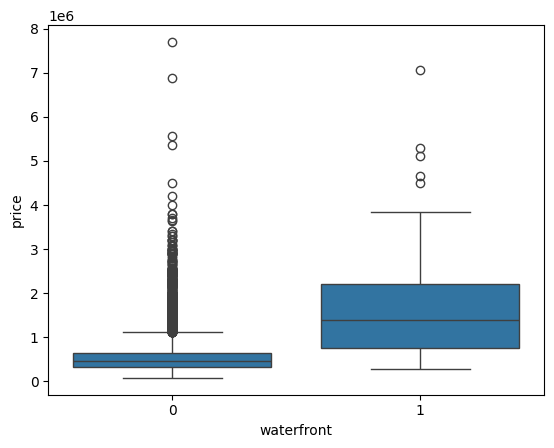

In [20]:
sns.boxplot(x='waterfront', y='price', data=df)
plt.show()

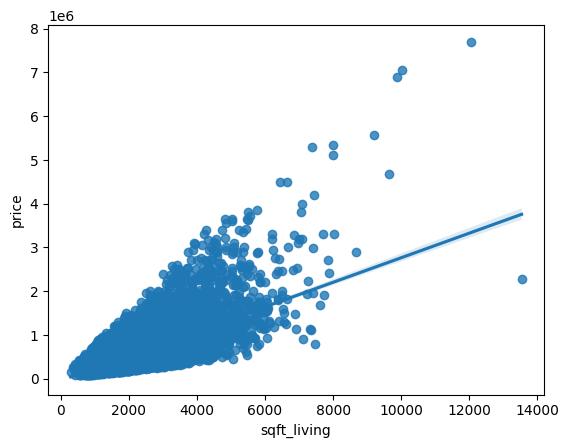

In [21]:
#Regression plot
#Relationship between sqft living and price:
sns.regplot(x="sqft_living",
            y="price",
            data=df)
plt.show()


In [22]:
#Correlation Matrix

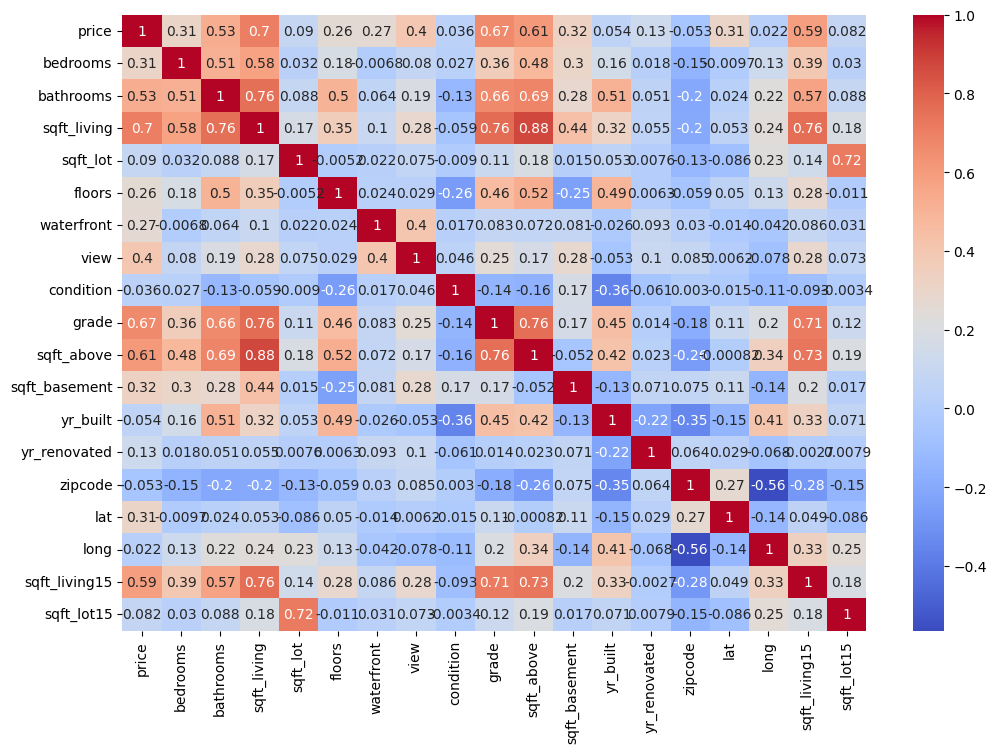

In [23]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [24]:
#find correlation with price
df.corr(numeric_only=True)['price'].sort_values()

zipcode         -0.053203
long             0.021626
condition        0.036362
yr_built         0.054012
sqft_lot15       0.082447
sqft_lot         0.089661
yr_renovated     0.126434
floors           0.256794
waterfront       0.266369
lat              0.307003
bedrooms         0.308797
sqft_basement    0.323816
view             0.397293
bathrooms        0.525738
sqft_living15    0.585379
sqft_above       0.605567
grade            0.667434
sqft_living      0.702035
price            1.000000
Name: price, dtype: float64

In [25]:
#Module 4: Model Development
#Linear Regression

In [26]:
#select Fetures
X=df[['sqft_living']]
Y=df['price']

lrm=LinearRegression()

In [27]:
#create model
lrm=LinearRegression()

In [28]:
lrm.fit(X,Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
Yhat=lrm.predict(X)

In [30]:
Yhat[:5]

array([287555.06702452, 677621.82640197, 172499.40418656, 506441.44998452,
       427866.85097324])

In [31]:
print(lrm.intercept_)

-43580.743094473146


In [32]:
print(lrm.coef_)

[280.6235679]


In [33]:
#Multple Linear regression

In [34]:
features=[
'bedrooms',
'bathrooms',
'sqft_living',
'sqft_lot',
'floors',
'waterfront'
]

In [35]:
features

['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront']

In [36]:
#train
X=df[features]

Y=df['price']

lm2=LinearRegression()

In [37]:
lm2.fit(X,Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
#predict
Yhat=lm2.predict(X)

In [39]:
Yhat[:4]

array([277316.68895194, 705888.78091143, 204652.7414241 , 474644.61473388])

In [40]:
#coefficients
print(lm2.intercept_)

73466.44234162883


In [41]:
print(lm2.coef_)

[-5.26813467e+04  7.18907903e+03  3.01781835e+02 -3.71205051e-01
  6.99951192e+02  7.93546947e+05]


In [42]:
#Polynomial Regression
#Create polynomial model:

In [43]:
x=df[['sqft_living']]
y=df['price']

poly=PolynomialFeatures(degree=2)

x_poly=poly.fit_transform(x)

model=LinearRegression()
model.fit(x_poly,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
yhat=model.predict(x_poly)
yhat[:5]

array([333175.85876367, 628792.4730121 , 274452.56182321, 480704.47690599,
       422344.10924677])

In [45]:
#Module 5: Model Evaluation and Refinement
#Split Data

In [46]:
X=df[features]

Y=df['price']


x_train,x_test,y_train,y_test=train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=1
)

In [47]:
#Train Model
lr=LinearRegression()

lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
yhat_test=lr.predict(x_test)
yhat[:5]

array([333175.85876367, 628792.4730121 , 274452.56182321, 480704.47690599,
       422344.10924677])

In [49]:
#R² Score
#Training accuracy:
lr.score(x_train,y_train)

0.537837710922253

In [50]:
#Testing Accuracy
lr.score(x_test,y_test)

0.5568420222159531

In [51]:
#Mean Squared Error

In [52]:
mse = mean_squared_error(y_test,yhat_test)
mse

76489497302.19508

In [53]:
#Ridge Regression

In [54]:
from sklearn.linear_model import Ridge


ridge=Ridge(alpha=0.1)

ridge.fit(x_train,y_train)

,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [55]:
#Prediction

In [56]:
ridge_pred=ridge.predict(x_test)

In [57]:
#Accuracy
ridge.score(x_test,y_test)

0.5568307746002918

In [58]:
#Polynomial Ridge pipeline
Input=[('scale',StandardScaler()),
       ('polynomial',PolynomialFeatures(degree=2)),
       ('model',Ridge(alpha=0.1))]


pipe=Pipeline(Input)


pipe.fit(x_train,y_train)

,steps,"[('scale', ...), ('polynomial', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,degree,2
,interaction_only,False
,include_bias,True
,order,'C'


In [65]:
#prediction
pipe_pred=pipe.predict(x_test)
pipe_pred[:5]

array([676157.78813059, 426684.23011829, 559086.04381546, 530179.69217847,
       380821.8806897 ])

In [67]:
print("R2 Score:",
      r2_score(y_test,pipe_pred))


print("MSE:",
      mean_squared_error(y_test,pipe_pred))

R2 Score: 0.6264767124207689
MSE: 64470482152.80294
